
===== Dataset ORIGINAL =====
Shape X: (569, 30) | Shape y: (569,)
Primeras 5 filas (X):
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   

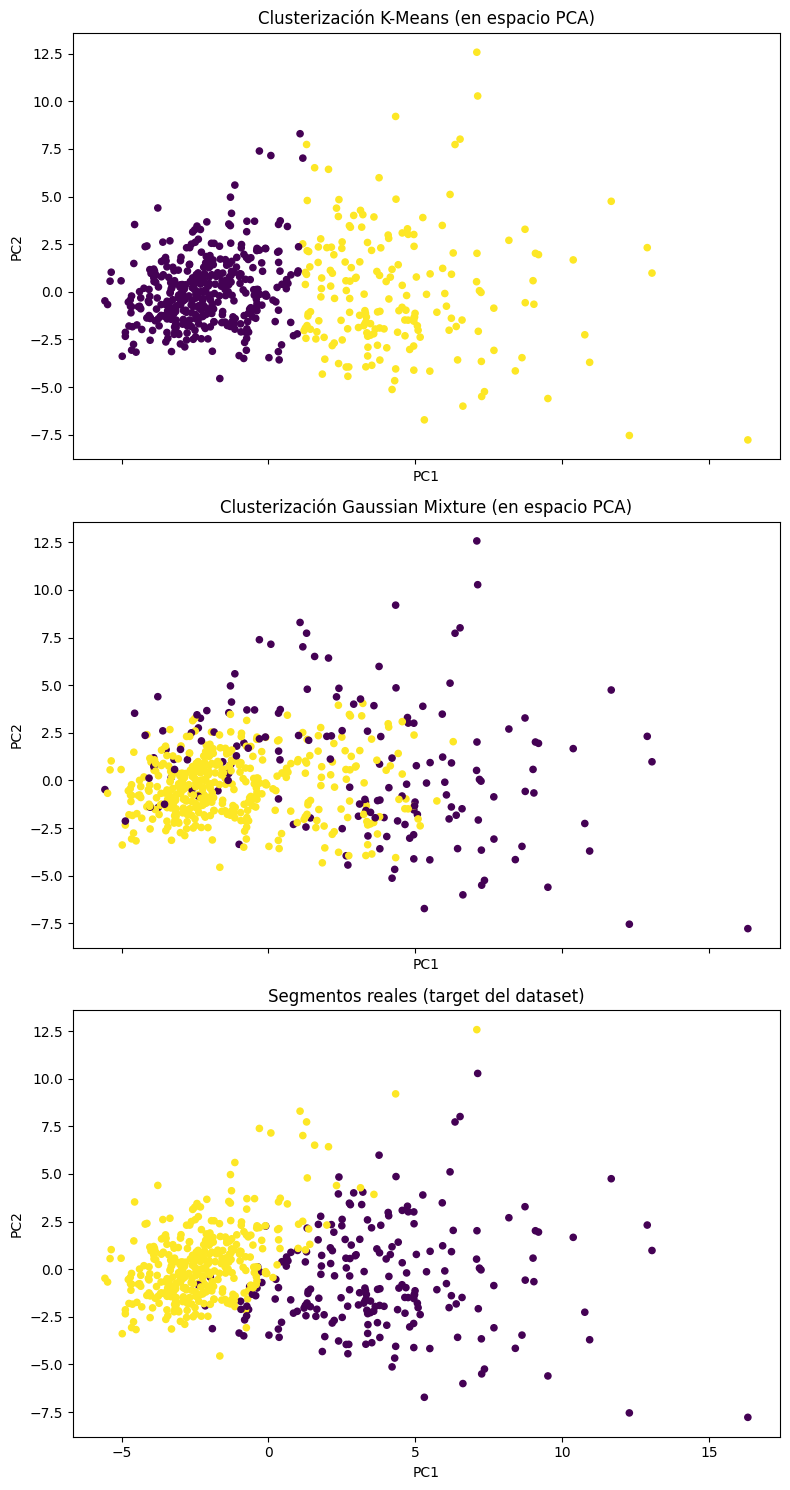

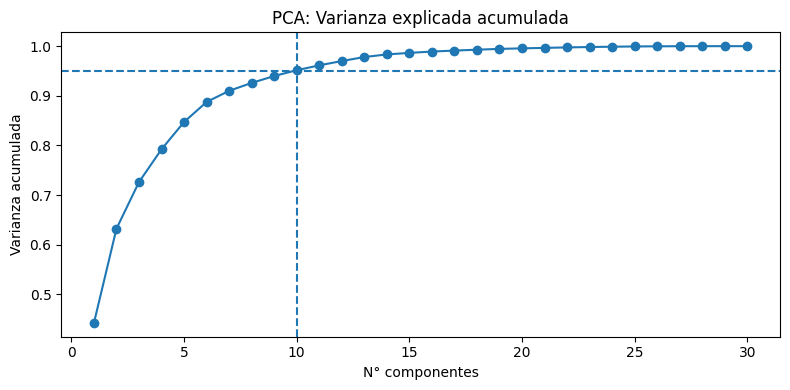

In [1]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)

def main(random_state: int = 42):
    # =========================
    # 1) Carga del dataset
    # =========================
    data = load_breast_cancer()
    X = pd.DataFrame(data.data, columns=data.feature_names)
    y = pd.Series(data.target, name="target")  # 0=malignant, 1=benign (en sklearn)

    print("\n===== Dataset ORIGINAL =====")
    print(f"Shape X: {X.shape} | Shape y: {y.shape}")
    print("Primeras 5 filas (X):")
    print(X.head())
    print("\nDistribución de clases (y):")
    print(y.value_counts().rename(index={0: "malignant(0)", 1: "benign(1)"}))

    # ==========================================
    # 2) Imputación de nulos (si existieran)
    # ==========================================
    n_nulls_before = X.isna().sum().sum()
    print("\n===== Nulos (antes) =====")
    print(f"Total nulos en X: {int(n_nulls_before)}")

    imputer = SimpleImputer(strategy="mean")
    X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

    n_nulls_after = X_imputed.isna().sum().sum()
    print("\n===== Nulos (después de imputar con media) =====")
    print(f"Total nulos en X_imputed: {int(n_nulls_after)}")

    # ==========================================
    # 3) Estandarización
    # ==========================================
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_imputed)

    # =====================================================
    # 4) PCA: análisis de dimensionalidad (varianza explicada)
    # =====================================================
    # PCA "completo" (n_components=None) para ver curva de varianza acumulada
    pca_full = PCA(n_components=None, random_state=random_state)
    X_pca_full = pca_full.fit_transform(X_scaled)

    explained_var = pca_full.explained_variance_ratio_
    cum_explained_var = np.cumsum(explained_var)

    # Elegimos k componentes para explicar al menos 95% de la varianza
    threshold = 0.95
    k_95 = int(np.argmax(cum_explained_var >= threshold) + 1)

    print("\n===== PCA: Análisis de dimensionalidad =====")
    print(f"Componentes totales posibles: {X.shape[1]}")
    print(f"Componentes para >= {int(threshold*100)}% varianza explicada: {k_95}")
    print(f"Varianza explicada acumulada con {k_95} componentes: {cum_explained_var[k_95-1]:.4f}")

    # =====================================================
    # 5) Reducción de dimensionalidad con PCA(k_95)
    # =====================================================
    pca = PCA(n_components=k_95, random_state=random_state)
    X_pca = pca.fit_transform(X_scaled)

    # Mostrar dataset "antes" (imputado) vs "después" PCA
    X_pca_df = pd.DataFrame(
        X_pca,
        columns=[f"PC{i+1}" for i in range(k_95)],
        index=X.index
    )

    print("\n===== Dataset antes de PCA (imputado) =====")
    print(f"Shape: {X_imputed.shape}")
    print(X_imputed.head())

    print("\n===== Dataset después de PCA =====")
    print(f"Shape: {X_pca_df.shape}")
    print(X_pca_df.head())

    # =====================================================
    # 6) Clusterización en espacio PCA
    #    - Usaremos 2 clusters porque el target real es binario
    # =====================================================
    n_clusters = 2

    # ---- K-Means
    kmeans = KMeans(n_clusters=n_clusters, n_init=20, random_state=random_state)
    km_labels = kmeans.fit_predict(X_pca)

    # ---- Gaussian Mixture
    gmm = GaussianMixture(n_components=n_clusters, covariance_type="full", random_state=random_state)
    gmm_labels = gmm.fit_predict(X_pca)

    # =====================================================
    # 7) Métricas de evaluación (no supervisadas y de alineación con y)
    # =====================================================
    # Silhouette score (requiere >=2 clusters y usa distancia en el espacio PCA)
    sil_km = silhouette_score(X_pca, km_labels)
    sil_gmm = silhouette_score(X_pca, gmm_labels)

    # Métricas de alineación con etiquetas reales (no “accuracy”, porque los labels pueden permutarse)
    ari_km = adjusted_rand_score(y, km_labels)
    ari_gmm = adjusted_rand_score(y, gmm_labels)

    nmi_km = normalized_mutual_info_score(y, km_labels)
    nmi_gmm = normalized_mutual_info_score(y, gmm_labels)

    print("\n===== Métricas =====")
    print(f"[KMeans]  Silhouette: {sil_km:.4f} | ARI: {ari_km:.4f} | NMI: {nmi_km:.4f}")
    print(f"[GMM]     Silhouette: {sil_gmm:.4f} | ARI: {ari_gmm:.4f} | NMI: {nmi_gmm:.4f}")

    # =====================================================
    # 8) Visualización: 3 gráficos en 1 columna
    #    Comparar KMeans vs GMM vs Segmentos reales
    #    (usamos PC1 y PC2 para graficar)
    # =====================================================
    if k_95 < 2:
        raise ValueError("PCA devolvió menos de 2 componentes; se requieren PC1 y PC2 para los scatter.")

    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(8, 15), sharex=True, sharey=True)

    axes[0].scatter(X_pca_df["PC1"], X_pca_df["PC2"], c=km_labels, s=20)
    axes[0].set_title("Clusterización K-Means (en espacio PCA)")
    axes[0].set_xlabel("PC1")
    axes[0].set_ylabel("PC2")

    axes[1].scatter(X_pca_df["PC1"], X_pca_df["PC2"], c=gmm_labels, s=20)
    axes[1].set_title("Clusterización Gaussian Mixture (en espacio PCA)")
    axes[1].set_xlabel("PC1")
    axes[1].set_ylabel("PC2")

    axes[2].scatter(X_pca_df["PC1"], X_pca_df["PC2"], c=y, s=20)
    axes[2].set_title("Segmentos reales (target del dataset)")
    axes[2].set_xlabel("PC1")
    axes[2].set_ylabel("PC2")

    plt.tight_layout()
    plt.show()

    # =====================================================
    # 9) Extra: gráfica de varianza explicada acumulada
    # =====================================================
    plt.figure(figsize=(8, 4))
    plt.plot(np.arange(1, len(cum_explained_var) + 1), cum_explained_var, marker="o")
    plt.axhline(threshold, linestyle="--")
    plt.axvline(k_95, linestyle="--")
    plt.title("PCA: Varianza explicada acumulada")
    plt.xlabel("N° componentes")
    plt.ylabel("Varianza acumulada")
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()



===== Dataset ORIGINAL =====
Shape X: (569, 30) | Shape y: (569,)
Primeras 5 filas (X):
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   

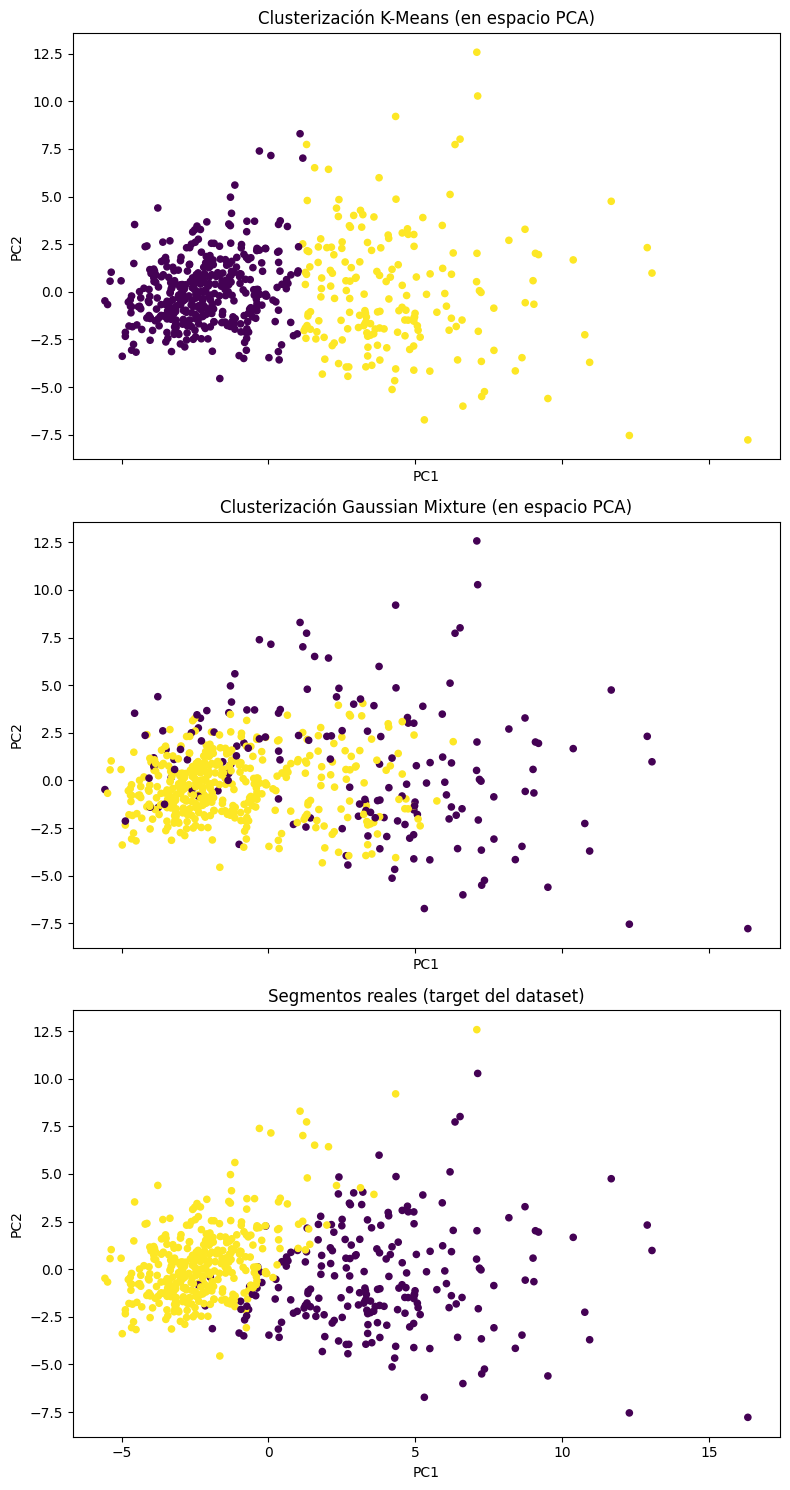

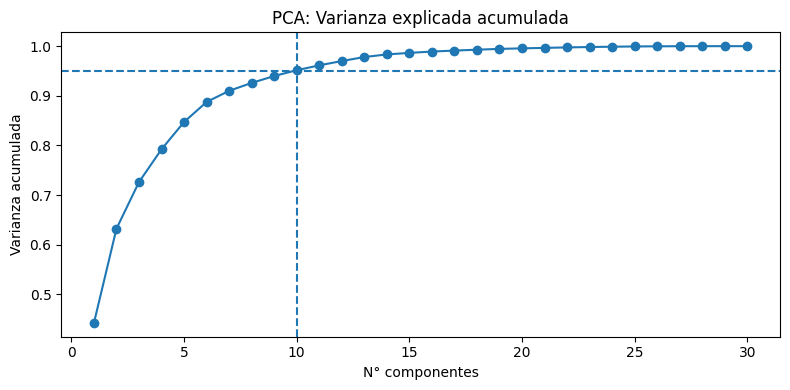

In [2]:
main()